# SCOPUS Search API

Hier testen wir SCOPUS API!

Die Anleitung für die SCOPUS SEARCH API ist [hier](https://dev.elsevier.com/documentation/SCOPUSSearchAPI.wadl) zu finden.  
Zur Formulierung der Abfrage gibt es noch [diese weiterführende Seite](https://dev.elsevier.com/sc_search_tips.html).

SCOPUS Search API ist durch ELSEVIER API key erreichbar. Weil verschiedene API-Schnittstelle von ELSEVIER angeboten sind, kann man mit einem API-Key auf unterschiedliche Datenquelle zugreifen.


In [1]:
import requests
import getpass

In [2]:
ELSEVIER_KEY = getpass.getpass()

 ········


In [22]:
scopus_search_url = "https://api.elsevier.com/content/search/scopus"

headers = {
    "X-ELS-APIKey": ELSEVIER_KEY
}

params = {
    "query": "OPENACCESS(1) AND DOCTYPE(bk)"
}

bsp_resp_1 = requests.get(scopus_search_url, headers=headers, params=params)
bsp_resp_1.status_code

200

In [23]:
import json
from IPython.display import JSON

result_bsp1 = bsp_resp_1.json()
JSON(result_bsp1)

<IPython.core.display.JSON object>

In [35]:
params2 = {
    "query": "KEY(Vermeer) AND SUBJAREA(ARTS)",
    "sort": "-pubyear",
    "count": 5
}

bsp_resp_2 = requests.get(scopus_search_url, headers=headers, params=params2)
bsp_resp_2.status_code



200

In [36]:
if bsp_resp_2.status_code == 200:
    data = bsp_resp_2.json()
    items = data["search-results"]["entry"]
    for x in items:
        print(x["dc:title"])
        
else:
    print(bsp_resp_2.status_code)

“VERMEER” BY TOMAS TRANSTRÖMER, OR A PAINTER ON A POET’S COUCH
The Vermeer Passion Review of Shlyapa Vermeera. XVII vek i rassvet global'nogo mira [Vermeer’s hat: The seventeenth century and the dawn of the global world], by T. Brook, trans. I. Litvinova (Moscow: Slovo, 2024), Vermeer: A Life Lost and Found, by A. Graham-Dixon (London: Allen Lane, 2025)
Ineffability? The Several Vermeers
A tale of two Skopos theories: (Re-)siting translation theory
Learning from Vermeer: What “The Allegory of Painting” Means for Clinical Theory


## Abstract Daten von Elservier

Wie am Anfang erwähnt, sind unterschiedliche Datenquelle zugreifbar.  
Hier als Beispiel schauen wir, wie man einen Abstract-Text herholen kann. 

Laut [der offiziellen Anleitung](https://dev.elsevier.com/documentation/AbstractRetrievalAPI.wadl) wird die Antwort der Abfrage in XML-Format (nicht in JSON-Format) zurückgegeben.

In [26]:
# Der Endpoint stammt aus dem Beispiel 1 - Das bedeutet, dass dieser URL über SCOPUS Search API automatisch erhältlich ist... 
ABSTRACT_ENDPOINT = "https://api.elsevier.com/content/abstract/scopus_id/105025085138"

print("Das erste Ergebnis aus dem Beispiel 1: " + result_bsp1["search-results"]["entry"][0]["prism:url"])

Das erste Ergebnis aus dem Beispiel 1: https://api.elsevier.com/content/abstract/scopus_id/105025085138


In [20]:
# Für Header übernehmen wir nach wie vor den API-Key von Elseviser
abstract_response = requests.get(ABSTRACT_ENDPOINT, headers=headers)
abstract_response.status_code

200

In [27]:
# Der Inhalt der Response ist XML:
print(abstract_response.text)

<abstracts-retrieval-response xmlns="http://www.elsevier.com/xml/svapi/abstract/dtd" xmlns:dn="http://www.elsevier.com/xml/svapi/abstract/dtd" xmlns:ait="http://www.elsevier.com/xml/ani/ait" xmlns:ce="http://www.elsevier.com/xml/ani/common" xmlns:cto="http://www.elsevier.com/xml/cto/dtd" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:prism="http://prismstandard.org/namespaces/basic/2.0/" xmlns:xocs="http://www.elsevier.com/xml/xocs/dtd" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"><coredata><prism:url>https://api.elsevier.com/content/abstract/scopus_id/105025085138</prism:url><dc:identifier>SCOPUS_ID:105025085138</dc:identifier><eid>2-s2.0-105025085138</eid><prism:doi>10.1515/9783110733457</prism:doi><dc:title>Necrodialogues and Media: Communicating with the Dead in the Twentieth and Twenty-First Centuries</dc:title><prism:aggregationType>Book</prism:aggregationType><srctype>b</srctype><subtype>bk</subtype><subtypeDescription>Book</subtypeDescription><citedby-count>0</cited

In [33]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(abstract_response.text, "lxml")
abstract_section = soup.find("abstract", { "xml:lang": "eng" })
abstract_text = abstract_section.find("ce:para").text
print(abstract_text)


This volume is an original contribution to the understanding of the various forms of communication with the dead. Terming them "necrodialogues", it examines these forms of communication in relation to cultural and ritual practices of necromancy and mediumism on the one hand, and to the development of technologies for establishing contact with the beyond on the other. While recent scholarship in media and cultural studies rejects the narrative that technological progress in modernity eclipsed religious experiences and occult practices, twentieth- and twenty-first-century literary studies, holding on to the secularization paradigm, still largely dismiss practices of communication with the dead as anti-modern. By bringing together perspectives from different disciplines, this volume emphasizes the interconnectedness of literary necrodialogues and other cultural and media practices of communicating with the dead. The main aim of the collection is to explore the cultural, historical, anthro

## Kombination SCOPUS Search und Abstract

Hier wollen wir ein Word-Wolke aus 5 Abstract-Texten erstellen. 5 Texte sind zu wenig, um eine statistisch sinnvolle Aussage daraus zu extrahieren. Aber hier geht es darum, zu zeigen, wan man aus den API-Datenquellen machen kann.  
Aus diesem Grund führen wir auch kein "Data cleaning" aus, mit dem die Textdaten für statistisches Verfahren bereinigt werden sollten...

In [37]:
params3 = {
    "query": "KEY(Vermeer) AND SUBJAREA(ARTS)",
    "sort": "-pubyear",
    "count": 10
}

In [38]:
# Durch try-except die Fehler bei Abfrage behandeln
try:
    combi_req = requests.get(scopus_search_url, headers=headers, params=params3)
    combi_result = combi_req.json()
    
except requests.exceptions.RequestException as e:
    raise SystemExit(e)

In [41]:
def get_abstract_response(url):
    try: 
        abstract_res = requests.get(url, headers=headers)
        return abstract_res.text
    except requests.exceptions.RequestException as e:
        raise SystemExit(e)


def extract_abstract(xml_data):
    soup = BeautifulSoup(xml_data, "lxml")
    abstract_section = soup.find("abstract", { "xml:lang": "eng" })
    abstract_text = abstract_section.find("ce:para").text
    return abstract_text
    

count = 0
abstract_collection = ""

for item in combi_result["search-results"]["entry"]:
    if count == 5:
        break

    if item.get("prism:url"):
        xml_data = get_abstract_response(item["prism:url"])
        abstract_collection += extract_abstract(xml_data)

    else: 
        continue

        
    
    

In [43]:
print(abstract_collection)

This article presents an interpretation of Tomas Transtrőmer's poem “Vermeer” from the perspective of psychoanalytic theory, which describes the creative process as an act of overcoming the depressive position. The poem is considered a testimony to the reception of a painting, in which the viewer discovers evidence of the crisis experienced by the artist and his successful overcoming of it—and as a creative act, repeating the painter's experience. The close reading of the ekphrasis takes into account the observations of art historians that the striking calmness of Vermeer's depictions finds a counterpoint in the recurring motifs of the map and the letter introduced by the painter. A similar technique used by Tranströmer in “Vermeer” is the interplay between “inside” and “outside,” resulting in important observations about the sources and essence of the creative act. In conclusion, a more general view of Tranströmer's lyrical anthropology of art and the creative act is proposed. It is c

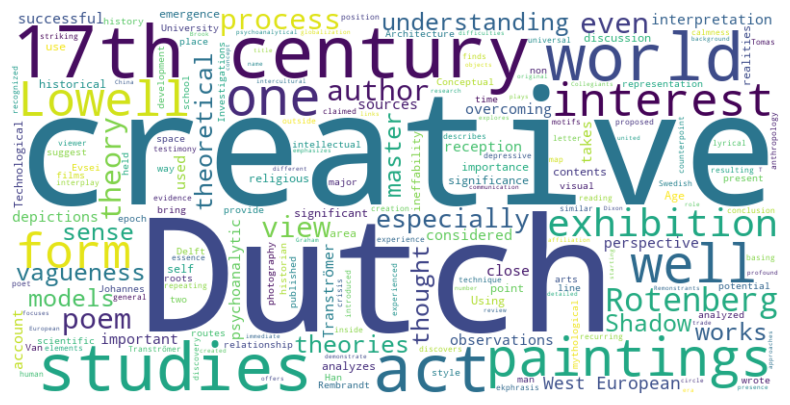

In [46]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Wir wollen die Stopwords manuell erweitern
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["Vermeer", "art", "painting", "painter", "chapter", "article", "artist", "S", "work"])

wc = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords).generate(abstract_collection)

# Word Cloud anzeigen
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

## Quiz


Gibt es einen Forschungstrend bei Subject Area "Computer Science" im Jahr 2026? Wie kann man das herausfinden?  
Formuliere die Suchabfrage und führe sie aus!